In [1]:
pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.3 MB/s eta 0:00:00


In [2]:
!pip -q install medmnist

import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import torchvision, matplotlib.pyplot as plt
from torchvision import transforms
from medmnist import PathMNIST, INFO

torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on:", device)

# ImageNet normalisation (the pretrained model expects this)
MEAN, STD = [0.485,0.456,0.406], [0.229,0.224,0.225]
class_names = INFO["pathmnist"]["label"]          # {"0":"adipose", ...}
print("Classes:", class_names)

def denorm(t):                                    # normalized (3,H,W) -> (H,W,3) 0..1 for display
    m = torch.tensor(MEAN).view(3,1,1); s = torch.tensor(STD).view(3,1,1)
    return (t.detach().cpu()*s+m).clamp(0,1).permute(1,2,0).numpy()

Running on: cpu
Classes: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}


100%|██████████| 1.07G/1.07G [00:40<00:00, 26.7MB/s]


train/val/test: 89996 10004 7180


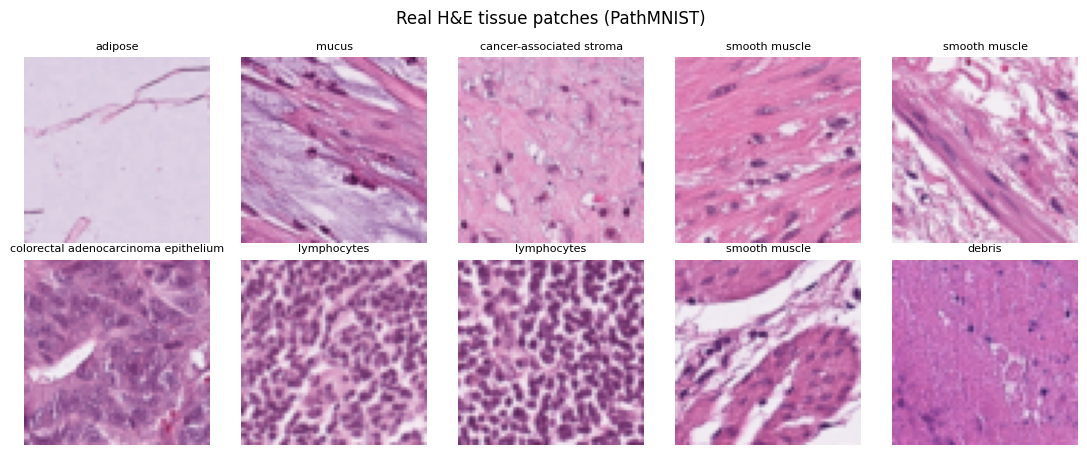

In [3]:
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

train_set = PathMNIST(split="train", transform=tf, download=True, size=64)
val_set   = PathMNIST(split="val",   transform=tf, download=True, size=64)
test_set  = PathMNIST(split="test",  transform=tf, download=True, size=64)
print("train/val/test:", len(train_set), len(val_set), len(test_set))

# show 10 raw patches with their labels
fig, axes = plt.subplots(2, 5, figsize=(11, 4.6))
for ax, i in zip(axes.ravel(), range(10)):
    ax.imshow(train_set.imgs[i])                  # raw uint8 image
    ax.set_title(class_names[str(int(train_set.labels[i][0]))], fontsize=8)
    ax.axis("off")
plt.suptitle("Real H&E tissue patches (PathMNIST)"); plt.tight_layout(); plt.show()

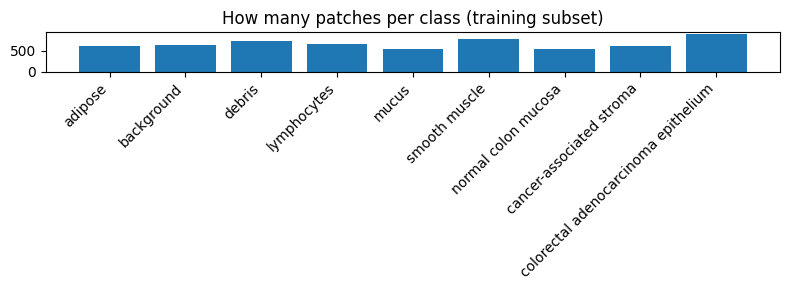

In [4]:
from torch.utils.data import Subset, DataLoader
rng = np.random.default_rng(0)
tr_idx = rng.choice(len(train_set), size=6000, replace=False)
va_idx = rng.choice(len(val_set),   size=1500, replace=False)

train_loader = DataLoader(Subset(train_set, tr_idx), batch_size=64, shuffle=True)
val_loader   = DataLoader(Subset(val_set,   va_idx), batch_size=64)

counts = np.bincount(train_set.labels[tr_idx].ravel(), minlength=9)
plt.figure(figsize=(8,3))
plt.bar([class_names[str(i)] for i in range(9)], counts)
plt.xticks(rotation=45, ha="right"); plt.title("How many patches per class (training subset)")
plt.tight_layout(); plt.show()

In [5]:
from torchvision.models import resnet18, ResNet18_Weights
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)   # downloads pretrained weights
model.fc = nn.Linear(model.fc.in_features, 9)              # 9 tissue classes
model = model.to(device)
print("Total parameters:", sum(p.numel() for p in model.parameters()))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 68.7MB/s]


Total parameters: 11181129


epoch 1: train_loss=0.580  val_acc=0.874
epoch 2: train_loss=0.322  val_acc=0.845
epoch 3: train_loss=0.231  val_acc=0.879


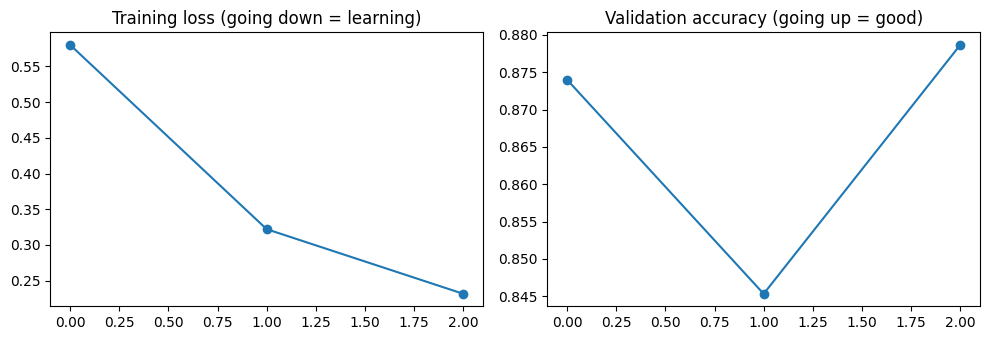

In [6]:
opt  = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()
hist = {"loss": [], "val_acc": []}

for epoch in range(3):
    model.train(); running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.squeeze(1).long().to(device)
        opt.zero_grad(); out = model(xb); loss = crit(out, yb)
        loss.backward(); opt.step(); running += loss.item()
    # validation accuracy
    model.eval(); correct = total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.squeeze(1).long().to(device)
            correct += (model(xb).argmax(1) == yb).sum().item(); total += len(yb)
    hist["loss"].append(running/len(train_loader)); hist["val_acc"].append(correct/total)
    print(f"epoch {epoch+1}: train_loss={hist['loss'][-1]:.3f}  val_acc={correct/total:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(hist["loss"], marker="o");    ax[0].set_title("Training loss (going down = learning)")
ax[1].plot(hist["val_acc"], marker="o"); ax[1].set_title("Validation accuracy (going up = good)")
plt.tight_layout(); plt.show()

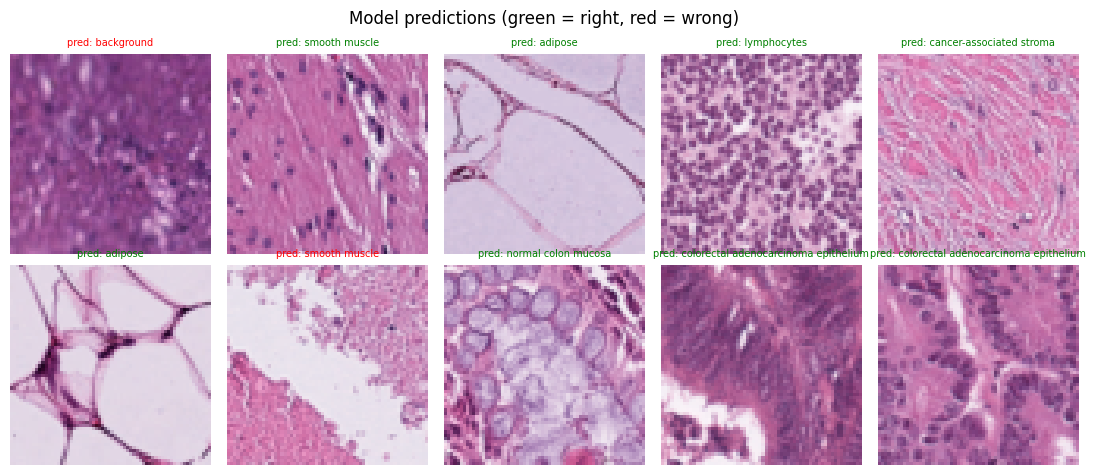

In [12]:
# OPTIONAL: see the model's guesses (green = right, red = wrong). No retraining.
xb, yb = next(iter(val_loader))
model.eval()
with torch.no_grad():
    preds = model(xb.to(device)).argmax(1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(11, 4.8))
for ax, i in zip(axes.ravel(), range(10)):
    true_c, pred_c = int(yb[i][0]), int(preds[i])
    ax.imshow(denorm(xb[i])); ax.axis("off")
    ax.set_title(f"pred: {class_names[str(pred_c)]}", fontsize=7,
                 color=("green" if true_c == pred_c else "red"))
plt.suptitle("Model predictions (green = right, red = wrong)"); plt.tight_layout(); plt.show()

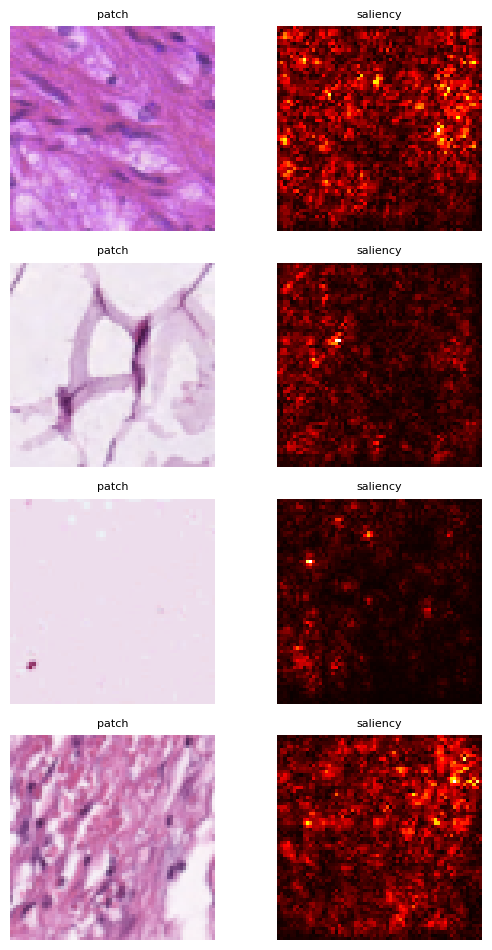

In [7]:
# pick 4 patches to explain (as normalized tensors)
ex_idx = [0, 1, 2, 3]
ex_x = torch.stack([val_set[i][0] for i in ex_idx])
ex_y = [int(val_set[i][1][0]) for i in ex_idx]

def saliency(model, x):                       # gradient of predicted class w.r.t. pixels
    model.eval()
    x = x.unsqueeze(0).to(device).requires_grad_(True)
    out = model(x); cls = int(out.argmax(1))
    model.zero_grad(); out[0, cls].backward()
    g = x.grad.detach()[0].abs().max(0)[0]    # strongest gradient across colour channels
    return ((g - g.min()) / (g.max() - g.min() + 1e-8)).cpu().numpy()

fig, axes = plt.subplots(len(ex_idx), 2, figsize=(6, 2.4*len(ex_idx)))
for r in range(len(ex_idx)):
    axes[r,0].imshow(denorm(ex_x[r])); axes[r,0].set_title("patch", fontsize=8); axes[r,0].axis("off")
    axes[r,1].imshow(saliency(model, ex_x[r]), cmap="hot"); axes[r,1].set_title("saliency", fontsize=8); axes[r,1].axis("off")
plt.tight_layout(); plt.show()

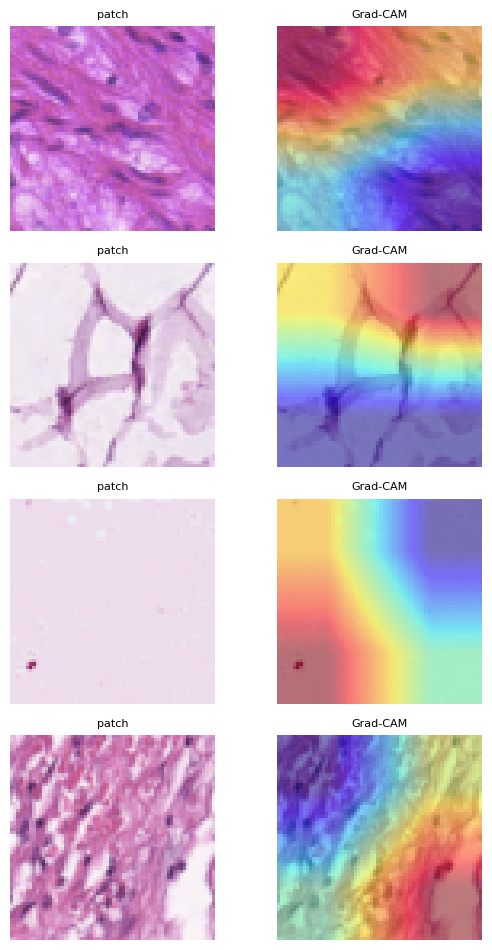

In [8]:
def grad_cam(model, x, layer):
    model.eval(); store = {}
    def hook(m, i, o):
        store["act"] = o
        o.register_hook(lambda g: store.__setitem__("grad", g))
    h = layer.register_forward_hook(hook)
    out = model(x.unsqueeze(0).to(device)); cls = int(out.argmax(1))
    model.zero_grad(); out[0, cls].backward()
    a, g = store["act"][0], store["grad"][0]
    cam = F.relu((g.mean(dim=(1,2))[:, None, None] * a).sum(0))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam = F.interpolate(cam[None,None], size=(64,64), mode="bilinear", align_corners=False)[0,0]
    h.remove(); return cam.detach().cpu().numpy()

fig, axes = plt.subplots(len(ex_idx), 2, figsize=(6, 2.4*len(ex_idx)))
for r in range(len(ex_idx)):
    axes[r,0].imshow(denorm(ex_x[r])); axes[r,0].set_title("patch", fontsize=8); axes[r,0].axis("off")
    axes[r,1].imshow(denorm(ex_x[r])); axes[r,1].imshow(grad_cam(model, ex_x[r], model.layer4), cmap="jet", alpha=0.5)
    axes[r,1].set_title("Grad-CAM", fontsize=8); axes[r,1].axis("off")
plt.tight_layout(); plt.show()

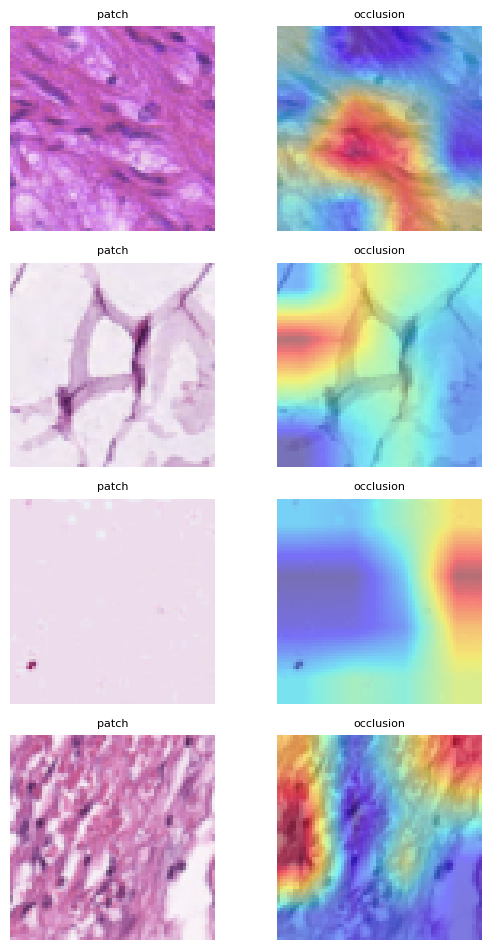

In [9]:
def occlusion(model, x, size=16, stride=16):
    model.eval()
    with torch.no_grad():
        base = F.softmax(model(x.unsqueeze(0).to(device)), 1)[0]
        cls = int(base.argmax()); base_p = float(base[cls])
    heat = np.zeros((64//stride, 64//stride))
    for i, yy in enumerate(range(0,64,stride)):
        for j, xx in enumerate(range(0,64,stride)):
            xo = x.clone(); xo[:, yy:yy+size, xx:xx+size] = 0.0
            with torch.no_grad():
                p = F.softmax(model(xo.unsqueeze(0).to(device)),1)[0,cls].item()
            heat[i,j] = base_p - p                       # how much hiding this spot hurt the score
    heat = (heat - heat.min())/(heat.max()-heat.min()+1e-8)
    return F.interpolate(torch.tensor(heat)[None,None].float(), size=(64,64),
                         mode="bilinear", align_corners=False)[0,0].numpy()

fig, axes = plt.subplots(len(ex_idx), 2, figsize=(6, 2.4*len(ex_idx)))
for r in range(len(ex_idx)):
    axes[r,0].imshow(denorm(ex_x[r])); axes[r,0].set_title("patch", fontsize=8); axes[r,0].axis("off")
    axes[r,1].imshow(denorm(ex_x[r])); axes[r,1].imshow(occlusion(model, ex_x[r]), cmap="jet", alpha=0.5)
    axes[r,1].set_title("occlusion", fontsize=8); axes[r,1].axis("off")
plt.tight_layout(); plt.show()

Stability under a tiny, invisible perturbation (closer to 1.0 = more stable):
  saliency  (pixel-level) : 0.784
  Grad-CAM  (region-level): 1.000
  occlusion (region-level): 0.993

Saliency: trained vs UNTRAINED model = 0.104
  (near 0 = saliency DID depend on the trained model -> it passes this check)


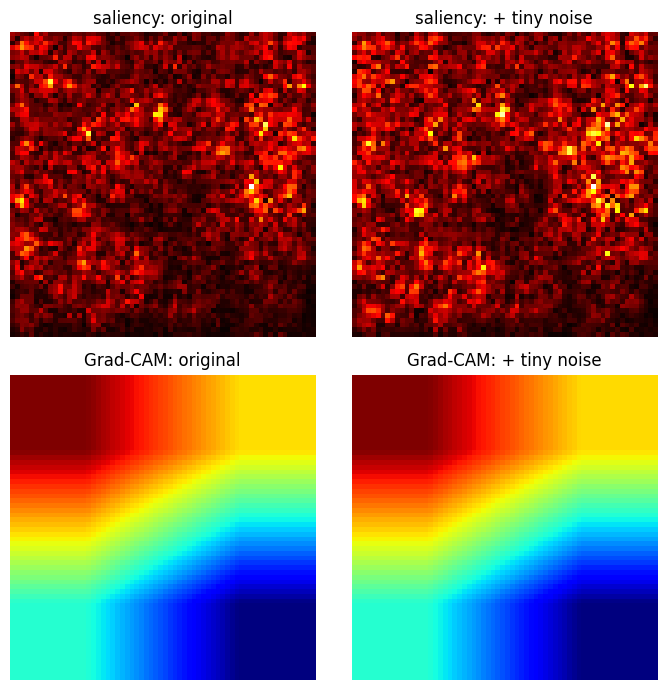

In [11]:
def corr(a, b): return float(np.corrcoef(a.ravel(), b.ravel())[0, 1])
x0 = ex_x[0]
x_noise = x0 + 0.05 * torch.randn_like(x0)        # a change too small to see

# 1) How STABLE is each method under the same tiny noise?  (closer to 1.0 = more stable)
print("Stability under a tiny, invisible perturbation (closer to 1.0 = more stable):")
print(f"  saliency  (pixel-level) : {corr(saliency(model, x0),               saliency(model, x_noise)):.3f}")
print(f"  Grad-CAM  (region-level): {corr(grad_cam(model, x0, model.layer4),  grad_cam(model, x_noise, model.layer4)):.3f}")
print(f"  occlusion (region-level): {corr(occlusion(model, x0),              occlusion(model, x_noise)):.3f}")

# 2) Sanity check (Adebayo): does saliency depend on the trained model at all?
rand_model = resnet18(weights=None); rand_model.fc = nn.Linear(512, 9); rand_model = rand_model.to(device)
print(f"\nSaliency: trained vs UNTRAINED model = {corr(saliency(model, x0), saliency(rand_model, x0)):.3f}")
print("  (near 0 = saliency DID depend on the trained model -> it passes this check)")

# 3) SEE it: raw saliency reshuffles more than Grad-CAM under the same tiny noise
fig, ax = plt.subplots(2, 2, figsize=(7, 7))
ax[0,0].imshow(saliency(model, x0), cmap="hot");                    ax[0,0].set_title("saliency: original")
ax[0,1].imshow(saliency(model, x_noise), cmap="hot");              ax[0,1].set_title("saliency: + tiny noise")
ax[1,0].imshow(grad_cam(model, x0, model.layer4), cmap="jet");     ax[1,0].set_title("Grad-CAM: original")
ax[1,1].imshow(grad_cam(model, x_noise, model.layer4), cmap="jet");ax[1,1].set_title("Grad-CAM: + tiny noise")
for a in ax.ravel(): a.axis("off")
plt.tight_layout(); plt.show()